# Explainability Layer — Attention Visualization & Token Highlighting
**ASHO-UAB Fake News Prediction — Phase 2**

This notebook implements the explainability layer for the PubMedBERT health-claim classifier.
Two attribution methods are combined:
- **Raw attention** (last transformer layer, averaged over heads) — fast proxy
- **Integrated Gradients** (Captum `LayerIntegratedGradients`) — more faithful attribution

Token highlights are then rendered side-by-side against the gold `explanation` field,
and quantified with ROUGE-1/2/L + BERTScore over the full validation split.

In [1]:
!pip install captum rouge-score bert-score -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 8.7 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 1.1 MB/s eta 0:00:00eta 0:00:01


## 1. Setup & Model Loading

In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from IPython.display import display, HTML
from transformers import AutoTokenizer, AutoModelForSequenceClassification

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

# ── paths ──────────────────────────────────────────────────────────────────────
DATA_DIR = '/kaggle/input/datasets/noasolcasale/pubhealth-gusgus127/PUBHEALTH'
MODEL_PATH = '/kaggle/input/datasets/noasolcasale/pubhealth-gusgus127/pubmedbert_smart_quick_best/pubmedbert_smart_quick_best'

# unzip if needed (model was zipped at end of baseline notebook)
#if not os.path.exists(MODEL_PATH):
 #   import zipfile
  #  with zipfile.ZipFile('pubmedbert_pubhealth_best.zip', 'r') as zf:
   #     zf.extractall('.')
    #print("Model unzipped.")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [3]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH, use_fast=True)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_PATH, 
    attn_implementation="eager",
    local_files_only=True
)
model.eval()
model = model.to(device)

id2label = model.config.id2label   # {0: 'true', 1: 'false', 2: 'mixture', 3: 'unproven'}
label2id = model.config.label2id
print("Labels:", id2label)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Labels: {0: 'true', 1: 'false', 2: 'mixture', 3: 'unproven'}


In [4]:
def load_split(path):
    df = pd.read_csv(path, sep='\t')
    df.dropna(subset=['claim', 'main_text', 'label'], inplace=True)
    df['labels'] = df['label'].map(label2id)
    df.dropna(subset=['labels'], inplace=True)
    df['labels'] = df['labels'].astype(int)
    df['text']   = df['claim'].astype(str) + ' [SEP] ' + df['main_text'].astype(str)
    df['explanation'] = df['explanation'].fillna('')
    return df.reset_index(drop=True)

train_df = load_split(f'{DATA_DIR}/train.tsv')
val_df   = load_split(f'{DATA_DIR}/dev.tsv')
test_df  = load_split(f'{DATA_DIR}/test.tsv')
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 9804 | Val: 1214 | Test: 1233


## 2. Attention Extraction

We extract the raw attention matrix from **layer 11** (last transformer layer), average over all 12 heads,
and read the **CLS row** — which represents how much attention the classification token pays to each input token.

In [ ]:
def tokenize(text, max_length=512):
    """Returns a dict of tensors on `device` and the decoded token list."""
    enc = tokenizer(
        text,
        truncation=True,
        max_length=max_length,
        return_tensors='pt',
        padding=False,
    )
    enc = {k: v.to(device) for k, v in enc.items()}
    tokens = tokenizer.convert_ids_to_tokens(enc['input_ids'][0])
    return enc, tokens


def get_attention_scores(text):
    """
    Returns:
        tokens       : list of str  (raw subword tokens)
        attn_scores  : np.ndarray (seq_len,)  normalised to [0,1]
        predicted    : int  (predicted class id)
        confidence   : float
    """
    enc, tokens = tokenize(text)
    with torch.no_grad():
        out = model(**enc, output_attentions=True)

    # last layer, CLS row, mean over 12 heads → (seq_len,)
    attn = out.attentions[-1][0].mean(dim=0)[0]   # (seq_len,)
    attn = attn.cpu().numpy()
    attn = attn / (attn.max() + 1e-8)            # normalise

    probs     = torch.softmax(out.logits, dim=-1)[0].cpu().numpy()
    predicted = int(probs.argmax())
    return tokens, attn, predicted, float(probs[predicted])


# quick smoke-test
sample = test_df.iloc[0]
_toks, _attn, _pred, _conf = get_attention_scores(sample['text'])
print(f"Predicted: {id2label[_pred]} ({_conf:.1%})  |  seq_len={len(_toks)}")
print("Top-5 attended tokens:",
      [_toks[i] for i in np.argsort(_attn)[::-1][:5]])

Predicted: unproven (56.4%)  |  seq_len=512
Top-5 attended tokens: ['[SEP]', '.', '.', '.', ',']


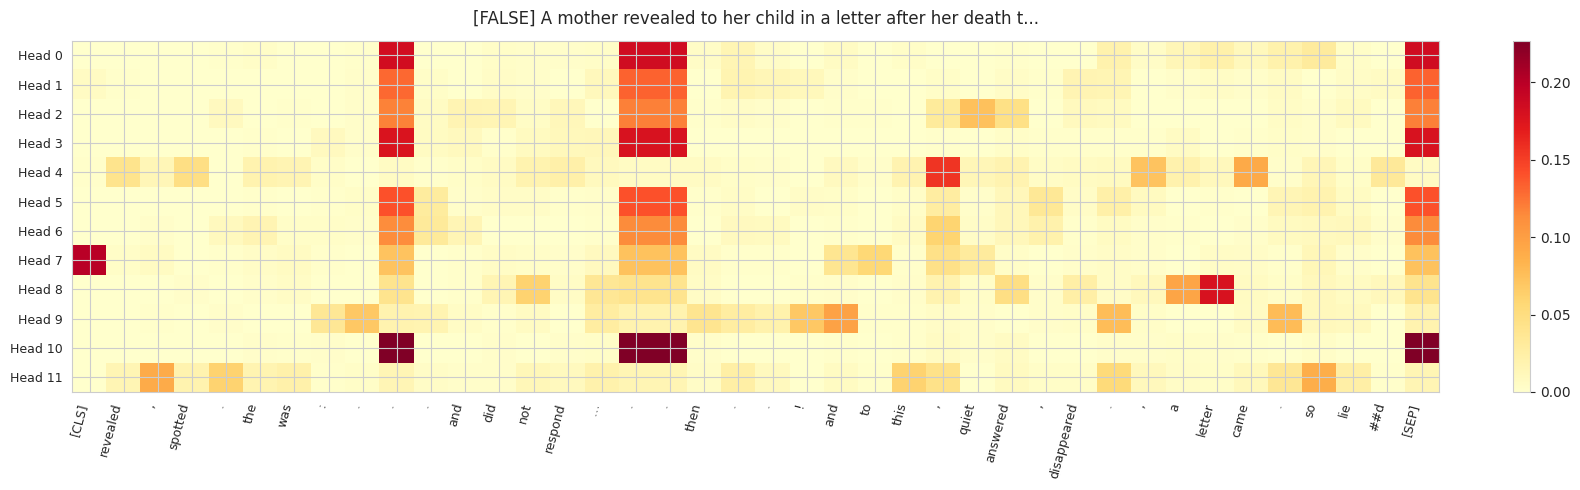

In [6]:
def plot_attention_heatmap(text, title='', top_n=40):
    """Visualise last-layer attention weights as a heatmap (all 12 heads, top-N tokens)."""
    enc, tokens = tokenize(text)
    with torch.no_grad():
        out = model(**enc, output_attentions=True)

    # last layer, all heads, CLS row → (12, seq_len)
    attn_heads = out.attentions[-1][0][:, 0, :].cpu().numpy()  # (12, seq_len)

    # keep only top_n most-attended tokens (by mean across heads)
    mean_attn = attn_heads.mean(axis=0)
    top_idx   = np.argsort(mean_attn)[::-1][:top_n]
    top_idx   = sorted(top_idx)
    top_tokens = [tokens[i] for i in top_idx]
    attn_sub  = attn_heads[:, top_idx]  # (12, top_n)

    fig, ax = plt.subplots(figsize=(max(14, top_n * 0.4), 5))
    im = ax.imshow(attn_sub, aspect='auto', cmap='YlOrRd', vmin=0)
    ax.set_xticks(range(top_n))
    ax.set_xticklabels(top_tokens, rotation=75, ha='right', fontsize=9)
    ax.set_yticks(range(12))
    ax.set_yticklabels([f'Head {h}' for h in range(12)], fontsize=9)
    ax.set_title(title or 'Layer 11 Attention — CLS → token (per head)', pad=12)
    plt.colorbar(im, ax=ax, fraction=0.03)
    plt.tight_layout()
    plt.show()


plot_attention_heatmap(
    test_df.iloc[0]['text'],
    title=f"[{test_df.iloc[0]['label'].upper()}] {test_df.iloc[0]['claim'][:60]}..."
)

## 3. Integrated Gradients (Captum)

`LayerIntegratedGradients` attributes the prediction to the embedding layer by integrating gradients along a
straight path from a baseline (all-PAD sequence) to the actual input.
This gives a **more faithful** importance score than raw attention.

In [ ]:
from captum.attr import LayerIntegratedGradients

def _forward_for_captum(input_ids, attention_mask, token_type_ids):
    out = model(
        input_ids=input_ids,
        attention_mask=attention_mask,
        token_type_ids=token_type_ids,
    )
    return out.logits


lig = LayerIntegratedGradients(_forward_for_captum, model.bert.embeddings)


def get_ig_scores(text, n_steps=20):
    """
    Returns:
        tokens      : list of str  (raw subword tokens)
        ig_scores   : np.ndarray (seq_len,)  normalised to [0,1]
        predicted   : int
        confidence  : float
        delta       : float  (convergence delta, lower is better)
    """
    enc, tokens = tokenize(text)
    input_ids       = enc['input_ids']
    attention_mask  = enc['attention_mask']
    token_type_ids  = enc.get('token_type_ids', torch.zeros_like(input_ids))

    baseline_ids = torch.full_like(input_ids, tokenizer.pad_token_id)

    with torch.no_grad():
        out = model(**enc)
    probs     = torch.softmax(out.logits, dim=-1)[0].detach().cpu().numpy()
    predicted = int(probs.argmax())

    attributions, delta = lig.attribute(
        inputs=input_ids,
        baselines=baseline_ids,
        target=predicted,
        additional_forward_args=(attention_mask, token_type_ids),
        n_steps=n_steps,
        internal_batch_size=2,
        return_convergence_delta=True,
    )
    # attributions: (1, seq_len, hidden_size) → sum over hidden dim, take abs
    ig_scores = attributions.sum(dim=-1).squeeze(0).abs().detach().cpu().numpy()
    ig_scores = ig_scores / (ig_scores.max() + 1e-8)

    return tokens, ig_scores, predicted, float(probs[predicted]), float(delta.abs().mean())


# smoke-test
_toks_ig, _ig, _pred_ig, _conf_ig, _delta = get_ig_scores(test_df.iloc[0]['text'])
print(f"Predicted: {id2label[_pred_ig]} ({_conf_ig:.1%})  |  convergence delta: {_delta:.4f}")
print("Top-5 IG tokens:",
      [_toks_ig[i] for i in np.argsort(_ig)[::-1][:5]])

Predicted: unproven (56.4%)  |  convergence delta: 0.4752
Top-5 IG tokens: ['shortened', 'regarding', 'respond', 'letter', 'disappeared']


In [8]:
import re

def split_into_spans(text, mode='sentence'):
    """
    Split text into spans for group-level attribution.
    mode='sentence' : split on . ? ! (keeps punctuation attached)
    mode='clause'   : also split on , ; : — and em-dash
    """
    if mode == 'sentence':
        pattern = r'(?<=[.?!])\s+'
    else:
        pattern = r'(?<=[.?!,;:])\s+'
    
    spans = re.split(pattern, text.strip())
    # Filter empty strings, keep order
    return [s.strip() for s in spans if s.strip()]

In [ ]:
def get_span_ig_scores(text, n_steps=30, mode='sentence'):
    """
    Returns spans sorted by aggregate IG score.
    
    Strategy: run IG once on the full text, then map each token back
    to the span it belongs to and sum scores within the span.
    
    Returns:
        spans_with_scores: list of (span_text, score) sorted desc by score
        ordered_top_spans: top spans in their ORIGINAL document order
    """
    # 1. Run IG as usual
    enc, tokens = tokenize(text)
    input_ids      = enc['input_ids']
    attention_mask = enc['attention_mask']
    token_type_ids = enc.get('token_type_ids', torch.zeros_like(input_ids))
    baseline_ids   = torch.full_like(input_ids, tokenizer.pad_token_id)

    with torch.no_grad():
        out = model(**enc)
    probs     = torch.softmax(out.logits, dim=-1)[0].detach().cpu().numpy()
    predicted = int(probs.argmax())

    attributions, delta = lig.attribute(
        inputs=input_ids,
        baselines=baseline_ids,
        target=predicted,
        additional_forward_args=(attention_mask, token_type_ids),
        n_steps=n_steps,
        internal_batch_size=2,
        return_convergence_delta=True,
    )
    ig_scores = attributions.sum(dim=-1).squeeze(0).abs().detach().cpu().numpy()
    # NOT normalise yet, we need raw magnitudes for aggregation

    # 2. Split text into spans
    spans = split_into_spans(text, mode=mode)
    
    # 3. For each span, re-tokenize and find its tokens' scores
    # We use character offsets to map span → token indices
    enc_with_offsets = tokenizer(
        text,
        truncation=True,
        max_length=512,
        return_offsets_mapping=True,
        return_tensors='pt',
    )
    offset_mapping = enc_with_offsets['offset_mapping'][0].numpy()  # (seq_len, 2)
    
    span_scores = []
    char_pos = 0
    for span in spans:
        # Find start/end char positions of this span in the original text
        span_start = text.find(span, char_pos)
        if span_start == -1:
            span_scores.append(0.0)
            continue
        span_end = span_start + len(span)
        char_pos = span_start + 1  # advance to avoid re-matching same span
        
        # Sum IG scores of all tokens whose character range overlaps this span
        span_ig = 0.0
        token_count = 0
        for tok_idx, (tok_start, tok_end) in enumerate(offset_mapping):
            if tok_start == tok_end:  # special tokens have (0,0)
                continue
            if tok_start >= span_start and tok_end <= span_end:
                span_ig += ig_scores[tok_idx]
                token_count += 1
        
        # Normalise by token count to avoid bias toward long spans
        span_scores.append(span_ig / max(token_count, 1))
    
    # 4. Pair spans with scores, sort by score descending
    pairs = list(zip(spans, span_scores))
    pairs_sorted = sorted(pairs, key=lambda x: x[1], reverse=True)
    
    # 5. Reconstruct candidate: take top-K spans, restore original order
    return pairs_sorted, predicted, float(probs[predicted]), float(delta.abs().mean())


def build_candidate_from_spans(pairs_sorted, top_k=3):
    """
    Take the top-k highest-scoring spans and join them in their
    ORIGINAL document order (not score order).
    This preserves readability and n-gram coherence for ROUGE.
    """
    top_k_pairs = pairs_sorted[:top_k]
    ordered = sorted(top_k_pairs, key=lambda x: pairs_sorted.index(x))
    return ' '.join(span for span, _ in ordered)

## 4. HTML Highlight Visualization

For each example the output shows:
- **Left panel** — input text with tokens coloured by IG attribution score (yellow → orange → red)
- **Right panel** — gold `explanation` field for direct human comparison
- **Top-10 tokens** ranked by importance

In [ ]:
def merge_subwords(tokens, scores):
    """Collapse ##-prefixed WordPiece subwords into whole words, summing their scores."""
    words, word_scores = [], []
    cur_word, cur_score = '', 0.0
    for tok, sc in zip(tokens, scores):
        if tok in ('[CLS]', '[SEP]', '[PAD]'):
            if cur_word:
                words.append(cur_word); word_scores.append(cur_score)
                cur_word, cur_score = '', 0.0
            words.append(tok); word_scores.append(float(sc))
        elif tok.startswith('##'):
            cur_word  += tok[2:]
            cur_score += float(sc)
        else:
            if cur_word:
                words.append(cur_word); word_scores.append(cur_score)
            cur_word, cur_score = tok, float(sc)
    if cur_word:
        words.append(cur_word); word_scores.append(cur_score)
    # re-normalise after merging
    arr = np.array(word_scores)
    arr = arr / (arr.max() + 1e-8)
    return words, arr.tolist()


LABEL_COLORS = {
    'true':     '#2e7d32',
    'false':    '#c62828',
    'mixture':  '#e65100',
    'unproven': '#6a1b9a',
}

def score_to_bg(score):
    """Map a [0,1] score to a yellow-orange-red background rgba string."""
    r = 255
    g = int(220 * (1.0 - score))
    b = int(180 * (1.0 - score * 0.9))
    a = score * 0.85 + 0.05
    return f'rgba({r},{g},{b},{a:.2f})'


def render_highlights(row, ig_scores, attention_scores, pairs_sorted=None, top_k=3):
    """
    Render a side-by-side card:
      - Left       : input text highlighted by IG token scores + top-10 token table
      - Centre-left: sentence-level IG highlights (top-k spans, readable text)  ← NEW
      - Centre-right: raw attention highlights
      - Right      : gold explanation field
    pairs_sorted : output of get_span_ig_scores() — list of (span, score) sorted desc.
                   If None the sentence panel is skipped gracefully.
    """
    text        = row['text']
    explanation = row['explanation']
    true_label  = row['label']

    enc, raw_tokens = tokenize(text)

    words_ig,   scores_ig   = merge_subwords(raw_tokens, ig_scores)
    words_attn, scores_attn = merge_subwords(raw_tokens, attention_scores)

    with torch.no_grad():
        out = model(**enc)
    probs     = torch.softmax(out.logits, dim=-1)[0].cpu().numpy()
    predicted = id2label[int(probs.argmax())]
    conf      = float(probs.max())

    pred_col = LABEL_COLORS.get(predicted, '#555')
    true_col = LABEL_COLORS.get(true_label, '#555')

    # token-level highlight builder
    def build_token_spans(words, scores, skip_special=True):
        parts = []
        for w, s in zip(words, scores):
            if skip_special and w in ('[CLS]', '[SEP]', '[PAD]'):
                if w == '[SEP]':
                    parts.append('<span style="color:#aaa;margin:0 6px;">|</span>')
                continue
            bg = score_to_bg(s)
            parts.append(
                f'<span style="background:{bg}; color:#000; font-weight:500; '
                f'border-radius:3px; padding:1px 3px; margin:1px; '
                f'display:inline-block; border:1px solid rgba(0,0,0,0.05);" '
                f'title="score:{s:.3f}">{w}</span>'
            )
        return ' '.join(parts)

    ig_html   = build_token_spans(words_ig,   scores_ig)
    attn_html = build_token_spans(words_attn, scores_attn)

    # top-10 token table
    tok_score_pairs = [
        (w, s) for w, s in zip(words_ig, scores_ig)
        if w not in ('[CLS]', '[SEP]', '[PAD]')
    ]
    tok_score_pairs.sort(key=lambda x: x[1], reverse=True)
    top10_rows = ''.join(
        f'<tr>'
        f'<td style="padding:2px 8px;font-size:12px;">{i+1}.</td>'
        f'<td style="padding:2px 8px;font-weight:bold;font-size:12px;'
        f'background:{score_to_bg(s)};border-radius:3px;">{w}</td>'
        f'<td style="padding:2px 8px;font-size:11px;color:#666;">{s:.3f}</td>'
        f'</tr>'
        for i, (w, s) in enumerate(tok_score_pairs[:10])
    )

    # sentence-level highlight builder 
    def build_sentence_panel(pairs_sorted, top_k):
        """
        Render every sentence in original document order.
        Top-k sentences get a coloured background; the rest are greyed out.
        A small badge shows the sentence rank by importance.
        """
        if not pairs_sorted:
            return '<em style="color:#888">No span data available.</em>'

        top_pairs  = pairs_sorted[:top_k]
        top_texts  = {span for span, _ in top_pairs}
        max_score  = max(s for _, s in top_pairs) if top_pairs else 1.0

        all_spans  = [span for span, _ in pairs_sorted]
        score_map  = {span: score for span, score in pairs_sorted}

        # Sort back to document order by character offset
        def span_offset(span):
            idx = text.find(span)
            return idx if idx != -1 else len(text)

        ordered_pairs = sorted(pairs_sorted, key=lambda x: span_offset(x[0]))

        # Build rank lookup (1 = most important)
        rank_map = {span: i + 1 for i, (span, _) in enumerate(pairs_sorted)}

        parts = []
        for span, score in ordered_pairs:
            norm = score / (max_score + 1e-8)
            if span in top_texts:
                bg    = score_to_bg(norm)
                rank  = rank_map[span]
                badge = (
                    f'<sup style="font-size:9px;color:#555;'
                    f'vertical-align:super;margin-left:2px;">#{rank}</sup>'
                )
                parts.append(
                    f'<span style="background:{bg}; color:#000; '
                    f'border-radius:4px; padding:2px 4px; '
                    f'display:inline; line-height:2.2; '
                    f'border:1px solid rgba(0,0,0,0.08);" '
                    f'title="importance rank #{rank}, score:{score:.3f}">'
                    f'{span}{badge}</span> '
                )
            else:
                parts.append(
                    f'<span style="color:#999;line-height:2.2;">{span}</span> '
                )

        # Summary line: the candidate string in document order
        candidate_spans = [s for s, _ in ordered_pairs if s in top_texts]
        candidate_text  = ' '.join(candidate_spans)

        summary = (
            f'<div style="margin-top:10px;padding:6px 8px;background:#fff3e0;'
            f'border-left:3px solid #ff9800;border-radius:3px;'
            f'font-size:11px;color:#555;">'
            f'<strong>Generated explanation (top-{top_k} sentences):</strong><br>'
            f'<span style="color:#333;">{candidate_text}</span>'
            f'</div>'
        )

        return ''.join(parts) + summary

    sentence_html = build_sentence_panel(pairs_sorted, top_k) if pairs_sorted is not None \
                    else '<em style="color:#888;font-size:12px;">Pass pairs_sorted to enable this panel.</em>'

    # assemble card
    html = f"""
    <div style="font-family:Arial,sans-serif;margin:16px 0;border:1px solid #ddd;
                border-radius:10px;overflow:hidden;">

      <!-- header -->
      <div style="background:#263238;color:white;padding:10px 16px;
                  display:flex;justify-content:space-between;align-items:center;">
        <strong style="font-size:14px;">Health Claim Explainability</strong>
        <div>
          <span style="background:{pred_col};color:white;padding:3px 10px;
                       border-radius:12px;font-size:12px;margin-right:8px;">
            Pred: {predicted} ({conf:.1%})
          </span>
          <span style="background:{true_col};color:white;padding:3px 10px;
                       border-radius:12px;font-size:12px;">
            True: {true_label}
          </span>
        </div>
      </div>

      <div style="display:flex;gap:0;">

        <!-- col 1: token-level IG -->
        <div style="flex:1.3;padding:14px 16px;border-right:1px solid #eee;
                    background:#fffde7;">
          <div style="font-size:12px;font-weight:bold;color:#222;
                      margin-bottom:8px;text-transform:uppercase;letter-spacing:0.5px;">
            Integrated Gradients (tokens)
          </div>
          <div style="line-height:2.4;font-size:13px;word-wrap:break-word;color:#000;">
            {ig_html}
          </div>
          <hr style="margin:10px 0;border-color:#ccc;"/>
          <div style="font-size:12px;font-weight:bold;color:#222;margin-bottom:6px;">
            Top Tokens
          </div>
          <table style="border-collapse:collapse;color:#000;">{top10_rows}</table>
        </div>

        <!-- col 2: sentence-level IG  ← NEW -->
        <div style="flex:1.3;padding:14px 16px;border-right:1px solid #eee;
                    background:#fce4ec;">
          <div style="font-size:12px;font-weight:bold;color:#222;
                      margin-bottom:8px;text-transform:uppercase;letter-spacing:0.5px;">
            Integrated Gradients (sentences)
          </div>
          <div style="font-size:13px;word-wrap:break-word;color:#000;">
            {sentence_html}
          </div>
        </div>

        <!-- col 3: raw attention -->
        <div style="flex:1.3;padding:14px 16px;border-right:1px solid #eee;
                    background:#fff8f1;">
          <div style="font-size:12px;font-weight:bold;color:#222;
                      margin-bottom:8px;text-transform:uppercase;letter-spacing:0.5px;">
            Raw Attention (Layer 11)
          </div>
          <div style="line-height:2.4;font-size:13px;word-wrap:break-word;color:#000;">
            {attn_html}
          </div>
        </div>

        <!-- col 4: gold explanation -->
        <div style="flex:0.9;padding:14px 16px;background:#f1f8e9;">
          <div style="font-size:12px;font-weight:bold;color:#222;
                      margin-bottom:8px;text-transform:uppercase;letter-spacing:0.5px;">
            Gold Explanation
          </div>
          <div style="font-size:13px;line-height:1.7;color:#000;">
            {explanation if explanation
             else '<em style="color:#666">No explanation available</em>'}
          </div>
        </div>

      </div>
    </div>
    """
    return html

print("render_highlights() ready.")

render_highlights() ready.


In [ ]:
# demo: one example per label class
demo_rows = (
    test_df.groupby('label', group_keys=False)
           .apply(lambda g: g.sample(1, random_state=42))
           .reset_index(drop=True)
)

for _, row in demo_rows.iterrows():
    toks_ig,   ig_sc,   _, _, _ = get_ig_scores(row['text'])
    toks_attn, attn_sc, _, _    = get_attention_scores(row['text'])
    pairs_sorted, _, _, _       = get_span_ig_scores(row['text'])          # ← add
    html = render_highlights(row, ig_sc, attn_sc, pairs_sorted=pairs_sorted)  # ← add kwarg
    display(HTML(html))

1.,fake,0.561
2.,does,0.526
3.,genuine,0.424
4.,not,0.414
5.,is,0.381
6.,appear,0.364
7.,this,0.355
8.,always,0.334
9.,we,0.316
10.,what,0.310


1.,oversimplifies,1.000
2.,says,0.585
3.,notably,0.544
4.,durbin,0.489
5.,decided,0.487
6.,a,0.415
7.,s,0.380
8.,director,0.367
9.,nuclear,0.346
10.,interview,0.339


1.,lawsuits,1.000
2.,jim,0.860
3.,said,0.763
4.,he,0.633
5.,t,0.600
6.,wasn,0.530
7.,statement,0.491
8.,verdicts,0.472
9.,cited,0.466
10.,onder,0.456


1.,roughly,1.000
2.,description,0.409
3.,breathing,0.205
4.,with,0.131
5.,fever,0.112
6.,but,0.109
7.,difficulty,0.101
8.,pneumonia,0.099
9.,this,0.094
10.,coronavirus,0.081


## 5. Quantitative Validation Against the `explanation` Field

**Method:** Extract the top-K (K=20) most important tokens from IG attribution,
reconstruct a candidate string, then compare against the gold `explanation` using:
- **ROUGE-1 / ROUGE-2 / ROUGE-L** (unigram / bigram / longest-common-subsequence overlap)
- **BERTScore F1** (contextual semantic similarity)

Evaluated on the full **validation split** (1,221 samples).

In [12]:
from rouge_score import rouge_scorer as rs
from bert_score import score as bert_score_fn

rouge_scorer = rs.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)


def top_k_tokens(words, scores, k=20):
    """Return a string of the top-k important words (excluding special tokens)."""
    pairs = [
        (w, s) for w, s in zip(words, scores)
        if w not in ('[CLS]', '[SEP]', '[PAD]')
    ]
    pairs.sort(key=lambda x: x[1], reverse=True)
    return ' '.join(w for w, _ in pairs[:k])


def compute_rouge(candidate, reference):
    if not reference.strip() or not candidate.strip():
        return {'r1': 0.0, 'r2': 0.0, 'rL': 0.0}
    res = rouge_scorer.score(reference, candidate)
    return {
        'r1': res['rouge1'].fmeasure,
        'r2': res['rouge2'].fmeasure,
        'rL': res['rougeL'].fmeasure,
    }


print("Rouge scorer ready.")

Rouge scorer ready.


In [ ]:
# run IG + ROUGE over full validation split 
# NOTE: this takes ~10 min on GPU
results = []

for idx, row in val_df.iterrows():
    if idx % 100 == 0:
        print(f"  {idx}/{len(val_df)} ...")
    try:
        pairs_sorted, pred, conf, delta = get_span_ig_scores(
            row['text'], n_steps=30, mode='sentence'
        )
        # Tune top_k: 3 sentences is usually ~50-100 words, closer to gold explanations
        candidate = build_candidate_from_spans(pairs_sorted, top_k=3)
        
        rouge = compute_rouge(candidate, row['explanation'])
        results.append({
            'idx':        idx,
            'label':      row['label'],
            'predicted':  id2label[pred],
            'correct':    row['label'] == id2label[pred],
            'confidence': conf,
            'candidate':  candidate,
            'explanation': row['explanation'],
            **rouge,
        })
    except Exception as e:
        print(f"  skipped idx={idx}: {e}")

results_df = pd.DataFrame(results)
print(f"\nProcessed {len(results_df)} samples.")
results_df.head(3)

  0/1214 ...
  100/1214 ...
  200/1214 ...
  300/1214 ...
  400/1214 ...
  500/1214 ...
  600/1214 ...
  700/1214 ...
  800/1214 ...
  900/1214 ...
  1000/1214 ...
  1100/1214 ...
  1200/1214 ...

Processed 1214 samples.


,idx,label,predicted,correct,confidence,candidate,explanation,r1,r2,rL
0,0,unproven,unproven,True,0.555486,Readers were left with a number of questions w...,Fellow Twitter users suggested @FierceFemtivis...,0.344086,0.109890,0.236559
1,1,true,true,True,0.950555,___ Information from: KSNT-TV. [SEP] Topeka te...,A bat found in northeastern Kansas has tested ...,0.378378,0.228571,0.378378
2,2,false,unproven,False,0.726621,"Parents at both schools, which share a site, w...",What's true: Some politicians complained that ...,0.128571,0.028986,0.085714


In [ ]:
# BERTScore (batch)
candidates  = results_df['candidate'].tolist()
references  = results_df['explanation'].tolist()

P, R, F = bert_score_fn(
    candidates, references,
    lang='en',
    verbose=True,
    device=str(device),
    batch_size=32,
)

results_df['bertscore_P'] = P.numpy()
results_df['bertscore_R'] = R.numpy()
results_df['bertscore_F'] = F.numpy()

print("\nBERTScore computation complete.")

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

calculating scores...
computing bert embedding.


  0%|          | 0/76 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/38 [00:00<?, ?it/s]

done in 39.43 seconds, 30.79 sentences/sec

BERTScore computation complete.


In [ ]:
# aggregate metrics table
metric_cols = ['r1', 'r2', 'rL', 'bertscore_F']
summary = results_df[metric_cols].agg(['mean', 'std']).T
summary.columns = ['Mean', 'Std']
summary.index = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L', 'BERTScore-F1']
summary = summary.round(4)
print("=" * 40)
print("  Validation-set explainability metrics")
print("=" * 40)
print(summary.to_string())
print("=" * 40)

  Validation-set explainability metrics
                Mean     Std
ROUGE-1       0.2222  0.0940
ROUGE-2       0.0469  0.0564
ROUGE-L       0.1339  0.0596
BERTScore-F1  0.8492  0.0198


## 6. Aggregate Analysis

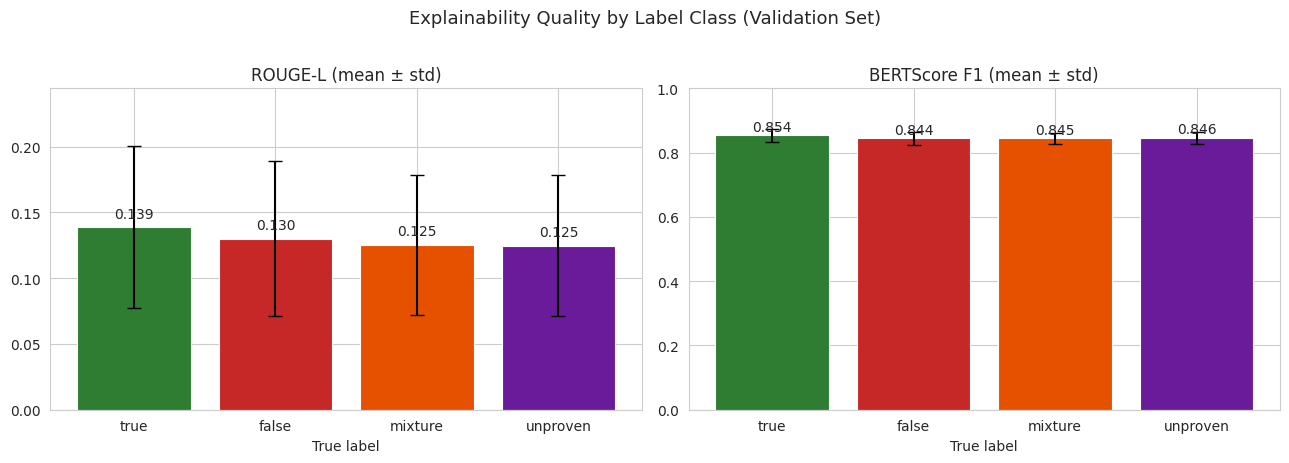

In [ ]:
# bar chart: metrics per label class 
label_order = ['true', 'false', 'mixture', 'unproven']
palette     = [LABEL_COLORS[l] for l in label_order]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, metric, title in zip(
    axes,
    ['rL', 'bertscore_F'],
    ['ROUGE-L (mean ± std)', 'BERTScore F1 (mean ± std)']
):
    grp  = results_df.groupby('label')[metric]
    means = grp.mean().reindex(label_order)
    stds  = grp.std().reindex(label_order)
    bars = ax.bar(label_order, means, yerr=stds, color=palette, capsize=5,
                  edgecolor='white', linewidth=0.8)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('True label')
    ax.set_ylim(0, min(1.0, means.max() * 1.4 + 0.05))
    for bar, m in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{m:.3f}', ha='center', va='bottom', fontsize=10)

plt.suptitle('Explainability Quality by Label Class (Validation Set)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

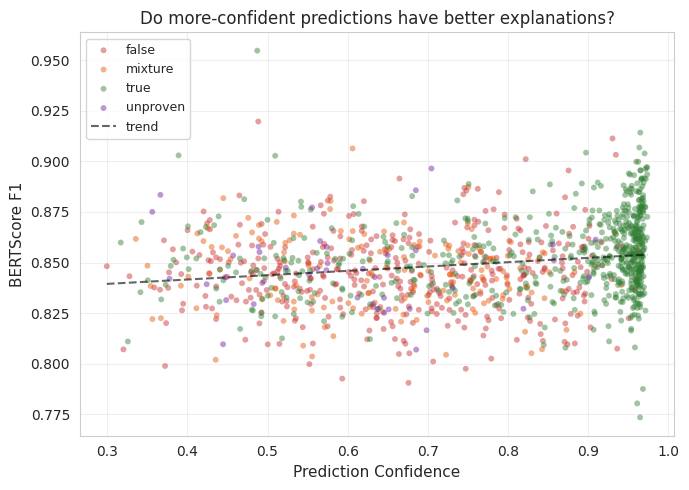

Pearson r (confidence vs BERTScore-F1): 0.199


In [ ]:
# scatter: prediction confidence vs BERTScore F1
fig, ax = plt.subplots(figsize=(7, 5))

for label, grp in results_df.groupby('label'):
    ax.scatter(
        grp['confidence'], grp['bertscore_F'],
        label=label, alpha=0.45, s=18,
        color=LABEL_COLORS.get(label, '#888'),
        edgecolors='none'
    )

# trend line (all points)
z = np.polyfit(results_df['confidence'], results_df['bertscore_F'], 1)
xr = np.linspace(results_df['confidence'].min(), results_df['confidence'].max(), 100)
ax.plot(xr, np.polyval(z, xr), 'k--', linewidth=1.5, alpha=0.6, label='trend')

ax.set_xlabel('Prediction Confidence', fontsize=11)
ax.set_ylabel('BERTScore F1', fontsize=11)
ax.set_title('Do more-confident predictions have better explanations?', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

corr = results_df[['confidence', 'bertscore_F']].corr().iloc[0, 1]
print(f"Pearson r (confidence vs BERTScore-F1): {corr:.3f}")

In [ ]:
# top-5 best and worst explained samples
display_cols = ['label', 'predicted', 'confidence', 'rL', 'bertscore_F',
                'candidate', 'explanation']

best5  = results_df.nlargest(5, 'bertscore_F')[display_cols]
worst5 = results_df.nsmallest(5, 'bertscore_F')[display_cols]

pd.set_option('display.max_colwidth', 80)
print("── TOP-5 best explained (highest BERTScore-F1) ──")
display(best5.round(3))

print("\n── TOP-5 worst explained (lowest BERTScore-F1) ──")
display(worst5.round(3))

── TOP-5 best explained (highest BERTScore-F1) ──


,label,predicted,confidence,rL,bertscore_F,candidate,explanation
516,true,unproven,0.487,0.806,0.955,[SEP] One in five people are drinking too much alcohol. Claim 1 of 3 21% of ...,21% of adults aged 16+ in England reported to an NHS Digital survey that the...
562,false,false,0.488,0.483,0.920,"When I left the Island, AFTER the storm had hit, they had anywhere from 6 to...","In a pair of early morning tweets, President Donald Trump rejected Puerto Ri..."
528,true,true,0.965,0.308,0.914,Reed says the federal money will be used to improve immunization levels and ...,U.S. Sen. Jack Reed says Rhode Island’s health department will receive $11.3...
71,false,false,0.930,0.364,0.911,"We rate it . The post telling you hand sanitizer will ""do nothing"" to stop t...",Health officials recommend the use of hand sanitizer to kill the coronavirus...
391,true,true,0.964,0.298,0.907,Heath officials recommend that anyone older than six-months should be vaccin...,New York officials have declared that the flu is “prevalent” in the state.



── TOP-5 worst explained (lowest BERTScore-F1) ──


,label,predicted,confidence,rL,bertscore_F,candidate,explanation
1046,true,true,0.965,0.073,0.774,Another theory? ___ The Associated Press Health and Science Department recei...,Disease trackers are calling a choir practice in Washington state a superspr...
1180,true,true,0.961,0.103,0.780,___ Follow Linda A. The AP is solely responsible for all content. ___ The As...,U.S. regulators Wednesday approved a new tuberculosis medicine that shortens...
689,true,true,0.968,0.082,0.788,expert said. expert said. ___ Follow Africa news at https://twitter.com/AP_A...,Zimbabwe is on the brink of man-made starvation and the number of people nee...
1185,false,unproven,0.676,0.089,0.791,"Upon arriving in Mount Kisco, this report continues, this CIA “hit team” bro...","Before the recent series of Clinton-related fabrications,Sorcha Faal claimed..."
261,false,false,0.593,0.111,0.793,Comments [SEP] TruthOrFiction.com has checked with several sourc...,A self-administered CPR procedure involving coughing can save you during a h...


In [ ]:
# full HTML visualization of best 3 examples
top3_idx = results_df.nlargest(3, 'bertscore_F')['idx'].tolist()

for idx in top3_idx:
    row = val_df.loc[idx]
    toks_ig,   ig_sc,   _, _, _ = get_ig_scores(row['text'])
    toks_attn, attn_sc, _, _    = get_attention_scores(row['text'])
    pairs_sorted, _, _, _       = get_span_ig_scores(row['text'])    
    html = render_highlights(row, ig_sc, attn_sc, pairs_sorted=pairs_sorted)
    display(HTML(html))

1.,3,0.491
2.,claim,0.337
3.,1,0.214
4.,.,0.193
5.,correct,0.137
6.,five,0.068
7.,of,0.063
8.,that,0.062
9.,.,0.060
10.,high,0.054


1.,rejected,1.000
2.,when,0.835
3.,false,0.813
4.,misleading,0.732
5.,he,0.606
6.,also,0.591
7.,sept,0.392
8.,tweets,0.339
9.,said,0.333
10.,aug,0.333


1.,says,1.000
2.,programs,0.858
3.,says,0.747
4.,providers,0.723
5.,vaccine,0.698
6.,centers,0.683
7.,department,0.671
8.,rhode,0.637
9.,says,0.621
10.,$,0.615


In [ ]:
# save results
results_df.to_csv('explainability_results_val.csv', index=False)
print("Results saved to explainability_results_val.csv")

print("\n── Summary for README update ──")
for metric, label in zip(['r1','r2','rL','bertscore_F'],
                          ['ROUGE-1','ROUGE-2','ROUGE-L','BERTScore-F1']):
    m = results_df[metric].mean()
    s = results_df[metric].std()
    print(f"  {label:16s}: {m:.4f} ± {s:.4f}")

Results saved to explainability_results_val.csv

── Summary for README update ──
  ROUGE-1         : 0.2222 ± 0.0940
  ROUGE-2         : 0.0469 ± 0.0564
  ROUGE-L         : 0.1339 ± 0.0596
  BERTScore-F1    : 0.8492 ± 0.0198
